Forme de la base de données : (32735, 16)

Premières lignes :
   year  month  day  dep_time  dep_delay  arr_time  arr_delay carrier tailnum  \
0  2013      6   30       940         15      1216         -4      VX  N626VA   
1  2013      5    7      1657         -3      2104         10      DL  N3760C   
2  2013     12    8       859         -1      1238         11      DL  N712TW   
3  2013      5   14      1841         -4      2122        -34      DL  N914DL   
4  2013      7   21      1102         -3      1230         -8      9E  N823AY   

   flight origin dest  air_time  distance  hour  minute  
0     407    JFK  LAX       313      2475     9      40  
1     329    JFK  SJU       216      1598    16      57  
2     422    JFK  LAX       376      2475     8      59  
3    2391    JFK  TPA       135      1005    18      41  
4    3652    LGA  ORF        50       296    11       2  

Nombre de vols après suppression des données manquantes : 32735
Retards au départ - Min: -21, Max: 130

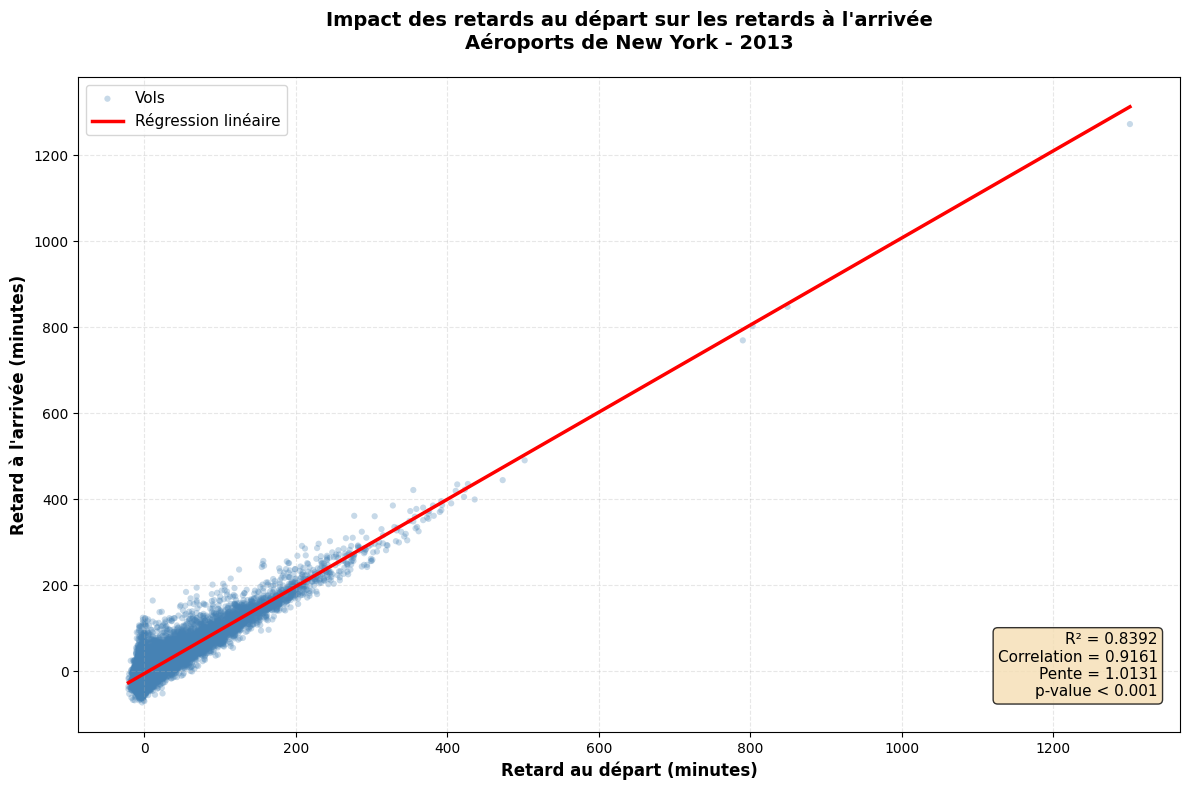


===== RÉSULTATS STATISTIQUES =====
Coefficient de corrélation (r) : 0.9161
R² (variance expliquée) : 0.8392
Pente : 1.0131
Intercept : -5.7707
P-value : 0.00e+00

Interprétation : Il existe une forte corrélation positive entre les retards au départ et à l'arrivée.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Charger les données
df = pd.read_csv('nycflights.csv')

print("Forme de la base de données :", df.shape)
print("\nPremières lignes :")
print(df.head())

# Nettoyer les données (supprimer les NaN)
df_clean = df.dropna(subset=['dep_delay', 'arr_delay']).copy()
print(f"\nNombre de vols après suppression des données manquantes : {len(df_clean)}")
print(f"Retards au départ - Min: {df_clean['dep_delay'].min()}, Max: {df_clean['dep_delay'].max()}")
print(f"Retards à l'arrivée - Min: {df_clean['arr_delay'].min()}, Max: {df_clean['arr_delay'].max()}")

# Calcul de la régression linéaire
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_clean['dep_delay'],
    df_clean['arr_delay']
)

# Créer la ligne de régression
x_line = np.array([df_clean['dep_delay'].min(), df_clean['dep_delay'].max()])
y_line = slope * x_line + intercept

# Créer le graphique
fig, ax = plt.subplots(figsize=(12, 8))

# Nuage de points
ax.scatter(df_clean['dep_delay'], df_clean['arr_delay'],
           alpha=0.3, s=20, color='steelblue', edgecolors='none', label='Vols')

# Ligne de régression
ax.plot(x_line, y_line, color='red', linewidth=2.5, label='Régression linéaire')

# Formatage du graphique
ax.set_xlabel('Retard au départ (minutes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Retard à l\'arrivée (minutes)', fontsize=12, fontweight='bold')
ax.set_title('Impact des retards au départ sur les retards à l\'arrivée\nAéroports de New York - 2013',
             fontsize=14, fontweight='bold', pad=20)

# Ajouter les statistiques
textstr = f'R² = {r_value**2:.4f}\nCorrelation = {r_value:.4f}\nPente = {slope:.4f}\np-value < 0.001'
ax.text(0.98, 0.05, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

# Afficher les résultats
print(f"\n===== RÉSULTATS STATISTIQUES =====")
print(f"Coefficient de corrélation (r) : {r_value:.4f}")
print(f"R² (variance expliquée) : {r_value**2:.4f}")
print(f"Pente : {slope:.4f}")
print(f"Intercept : {intercept:.4f}")
print(f"P-value : {p_value:.2e}")
print(f"\nInterprétation : Il existe une forte corrélation positive entre les retards au départ et à l'arrivée.")